In [1]:
from pathlib import Path
import pandas as pd
import re

BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/experiments")
OUT_DIR = Path("/data/shared/fsibilla/clean_code/Q1/across_experiments_sensitivity")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PATTERN = "results/evaluation/eval_adm1_seed_metrics_train_*.csv"
FILE_REGEX = re.compile(r"eval_adm1_seed_metrics_train_(.+)\.csv$")

In [2]:
all_files = sorted(BASE_DIR.glob(f"*/{PATTERN}"))
len(all_files), all_files[:5]

(32,
 [PosixPath('/data/shared/fsibilla/clean_code/Q1/experiments/eth_micron/results/evaluation/eval_adm1_seed_metrics_train_1.csv'),
  PosixPath('/data/shared/fsibilla/clean_code/Q1/experiments/eth_micron/results/evaluation/eval_adm1_seed_metrics_train_2.csv'),
  PosixPath('/data/shared/fsibilla/clean_code/Q1/experiments/eth_micron/results/evaluation/eval_adm1_seed_metrics_train_4.csv'),
  PosixPath('/data/shared/fsibilla/clean_code/Q1/experiments/eth_micron/results/evaluation/eval_adm1_seed_metrics_train_8.csv'),
  PosixPath('/data/shared/fsibilla/clean_code/Q1/experiments/lka_micron/results/evaluation/eval_adm1_seed_metrics_train_1.csv')])

In [3]:
records = []

for file_path in all_files:
    experiment = file_path.parts[-4]  # .../experiments/{experiment}/results/evaluation/file.csv
    
    match = FILE_REGEX.match(file_path.name)
    if match is None:
        print(f"Skipping unrecognized file name: {file_path}")
        continue
    
    size_str = match.group(1)
    
    # convert size to numeric when possible
    try:
        size = int(size_str)
    except ValueError:
        try:
            size = float(size_str)
        except ValueError:
            size = size_str
    
    df = pd.read_csv(file_path)
    df["experiment"] = experiment
    df["size"] = size
    df["source_file"] = str(file_path)
    
    records.append(df)

print(f"Loaded {len(records)} files")

Loaded 32 files


In [4]:
merged_df = pd.concat(records, ignore_index=True)

print(merged_df.shape)
merged_df.head()

(14300, 19)


,seed,adm1_code,adm1_name,adm1geometry,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,emd_over,variability_intrinsic,absmeanerr_gen,absmeanerr_nat,absmeanerr_over,experiment,size,source_file
0,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",va_ai,782,782,131,782,0.312715,0.181812,0.617177,0.214577,0.626827,0.488111,1.459668,eth_micron,1,/data/shared/fsibilla/clean_code/Q1/experiment...
1,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",fol_ai,782,782,131,782,0.373447,0.412934,0.425589,0.112310,1.019866,1.203967,1.188854,eth_micron,1,/data/shared/fsibilla/clean_code/Q1/experiment...
2,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",vb12_ai,782,782,131,782,0.782882,0.108193,0.957640,0.180890,3.232597,0.046733,3.957866,eth_micron,1,/data/shared/fsibilla/clean_code/Q1/experiment...
3,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",fe_ai,782,782,131,782,0.115920,0.243963,0.291900,0.215984,0.075906,0.695226,0.324903,eth_micron,1,/data/shared/fsibilla/clean_code/Q1/experiment...
4,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",zn_ai,782,782,131,782,0.227432,0.369971,0.368300,0.207562,0.229555,1.063611,0.440390,eth_micron,1,/data/shared/fsibilla/clean_code/Q1/experiment...


In [5]:
out_csv = OUT_DIR / "merged_all_experiments.csv"
merged_df.to_csv(out_csv, index=False)

print(f"Saved merged file to:\n{out_csv}")

Saved merged file to:
/data/shared/fsibilla/clean_code/Q1/across_experiments_sensitivity/merged_all_experiments.csv


## Visualize

In [6]:
# aggregate by experiment and size, then compute mean and std of EMD improvement

df = merged_df.copy()

df["imp_emd"] = df["emd_over"] - df["emd_gen"]
df["imp_abs"] = df["absmeanerr_over"] - df["absmeanerr_gen"]

df[["experiment", "size", "adm1_code", "target", "seed", "imp_emd", "imp_abs"]].head()

,experiment,size,adm1_code,target,seed,imp_emd,imp_abs
0,eth_micron,1,Addis Ababa,va_ai,1,0.304462,0.832841
1,eth_micron,1,Addis Ababa,fol_ai,1,0.052142,0.168988
2,eth_micron,1,Addis Ababa,vb12_ai,1,0.174757,0.725270
3,eth_micron,1,Addis Ababa,fe_ai,1,0.175980,0.248997
4,eth_micron,1,Addis Ababa,zn_ai,1,0.140868,0.210835


In [7]:
import numpy as np

group_cols = ["experiment", "size", "adm1_code", "target"]

seed_avg = (
    df.groupby(group_cols)
      .agg(
          imp_emd_mean=("imp_emd", "mean"),
          imp_emd_sd=("imp_emd", lambda x: x.std(ddof=1)),
          n_seeds=("imp_emd", "count"),
          imp_abs_mean=("imp_abs", "mean"),
          imp_abs_sd=("imp_abs", lambda x: x.std(ddof=1)),
      )
      .reset_index()
)

seed_avg["imp_emd_se"] = seed_avg["imp_emd_sd"] / np.sqrt(seed_avg["n_seeds"])
seed_avg["imp_abs_se"] = seed_avg["imp_abs_sd"] / np.sqrt(seed_avg["n_seeds"])

seed_avg.head()

,experiment,size,adm1_code,target,imp_emd_mean,imp_emd_sd,n_seeds,imp_abs_mean,imp_abs_sd,imp_emd_se,imp_abs_se
0,eth_micron,1,Addis Ababa,avg_adult_education,0.167806,0.140064,5,0.405159,0.347928,0.062639,0.155598
1,eth_micron,1,Addis Ababa,fe_ai,0.245128,0.117074,5,0.568591,0.476349,0.052357,0.213030
2,eth_micron,1,Addis Ababa,fol_ai,0.137824,0.085045,5,0.380341,0.270294,0.038033,0.120879
3,eth_micron,1,Addis Ababa,log_exp,0.035635,0.045601,5,0.113839,0.183080,0.020393,0.081876
4,eth_micron,1,Addis Ababa,va_ai,0.097241,0.191839,5,0.158717,0.477935,0.085793,0.213739


In [8]:
# handle groups with only one seed: std/se become NaN -> set to 0
seed_avg["imp_emd_sd"] = seed_avg["imp_emd_sd"].fillna(0.0)
seed_avg["imp_abs_sd"] = seed_avg["imp_abs_sd"].fillna(0.0)
seed_avg["imp_emd_se"] = seed_avg["imp_emd_se"].fillna(0.0)
seed_avg["imp_abs_se"] = seed_avg["imp_abs_se"].fillna(0.0)

seed_avg.head()

,experiment,size,adm1_code,target,imp_emd_mean,imp_emd_sd,n_seeds,imp_abs_mean,imp_abs_sd,imp_emd_se,imp_abs_se
0,eth_micron,1,Addis Ababa,avg_adult_education,0.167806,0.140064,5,0.405159,0.347928,0.062639,0.155598
1,eth_micron,1,Addis Ababa,fe_ai,0.245128,0.117074,5,0.568591,0.476349,0.052357,0.213030
2,eth_micron,1,Addis Ababa,fol_ai,0.137824,0.085045,5,0.380341,0.270294,0.038033,0.120879
3,eth_micron,1,Addis Ababa,log_exp,0.035635,0.045601,5,0.113839,0.183080,0.020393,0.081876
4,eth_micron,1,Addis Ababa,va_ai,0.097241,0.191839,5,0.158717,0.477935,0.085793,0.213739


In [9]:
def aggregate_with_propagated_uncertainty(group: pd.DataFrame) -> pd.Series:
    imp_emd = group["imp_emd_mean"].mean()
    imp_abs = group["imp_abs_mean"].mean()

    emd_std = group["imp_emd_mean"].std(ddof=1)
    abs_std = group["imp_abs_mean"].std(ddof=1)

    if pd.isna(emd_std):
        emd_std = 0.0
    if pd.isna(abs_std):
        abs_std = 0.0

    return pd.Series({
        "imp_emd": imp_emd,
        "imp_abs": imp_abs,
        "emd_std": emd_std,
        "abs_std": abs_std,
        "n_adm1_target_groups": len(group),
        "mean_seed_count": group["n_seeds"].mean(),
    })

In [10]:
avg_df = (
    seed_avg.groupby(["experiment", "size"])
            .apply(aggregate_with_propagated_uncertainty)
            .reset_index()
            .sort_values(["experiment", "size"])
            .reset_index(drop=True)
)

avg_df.head()

/tmp/ipykernel_1408019/1139741625.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_with_propagated_uncertainty)


,experiment,size,imp_emd,imp_abs,emd_std,abs_std,n_adm1_target_groups,mean_seed_count
0,eth_micron,1,0.150022,0.373262,0.189419,0.577151,77.0,5.0
1,eth_micron,2,0.081627,0.171731,0.141943,0.467041,77.0,5.0
2,eth_micron,4,0.051192,0.137392,0.119546,0.393390,77.0,5.0
3,eth_micron,8,-0.011449,-0.043846,0.077269,0.275750,77.0,5.0
4,lka_micron,1,0.133169,0.614535,0.105284,0.758893,63.0,5.0


In [11]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# Replace these with the exact 8 experiment names, nicknames, and colors you used before.
# Keys must match avg_df["experiment"] exactly.

EXPERIMENT_STYLE = {
    "eth_micron": {"label": "Ethiopia ESS",   "color": "#117733"},
    "lka_micron": {"label": "Sri Lanka HIES", "color": "#EE7733"},
    "lka_vam":    {"label": "Sri Lanka VAM",  "color": "#4477AA"},
    "moz_vam":    {"label": "Mozambique VAM", "color": "#CC79A7"},
    "nga_micron": {"label": "Nigeria NLSS",   "color": "#88CC44"},
    "nga_mics":   {"label": "Nigeria MICS",   "color": "#DDCC77"},
    "yem_mvam":   {"label": "Yemen mVAM",     "color": "#AA7744"},
    "zwe_mics":   {"label": "Zimbabwe MICS",  "color": "#7B4F9D"},
}

experiments_in_df = list(avg_df["experiment"].drop_duplicates())
print("Experiments in avg_df:")
print(experiments_in_df)

Experiments in avg_df:
['eth_micron', 'lka_micron', 'lka_vam', 'moz_vam', 'nga_micron', 'nga_mics', 'yem_mvam', 'zwe_mics']


In [13]:
# Safety check
missing_styles = [exp for exp in avg_df["experiment"].unique() if exp not in EXPERIMENT_STYLE]
if missing_styles:
    raise ValueError(
        "Missing style entries for these experiments:\n"
        + "\n".join(missing_styles)
    )

In [14]:
# Keep plotting order consistent with your style dict
experiment_order = [exp for exp in EXPERIMENT_STYLE if exp in avg_df["experiment"].unique()]

plot_df = avg_df.copy()
plot_df["size"] = pd.to_numeric(plot_df["size"], errors="coerce")
plot_df = plot_df.sort_values(["experiment", "size"]).reset_index(drop=True)

experiment_order

['eth_micron',
 'lka_micron',
 'lka_vam',
 'moz_vam',
 'nga_micron',
 'nga_mics',
 'yem_mvam',
 'zwe_mics']

In [15]:
def plot_metric_grid(
    df: pd.DataFrame,
    mean_col: str,
    std_col: str,
    figure_title: str,
    out_path: str | None = None,
    nrows: int = 2,
    ncols: int = 4,
    figsize: tuple = (6.0, 3.0),
):
    FS_TITLE  = 9
    FS_AXES   = 9
    FS_TICK   = 6
 
    TITLE_LABELS = {
        "eth_micron": "Ethiopia\nESS",
        "lka_micron": "Sri Lanka\nHIES",
        "lka_vam":    "Sri Lanka\nVAM",
        "moz_vam":    "Mozambique\nVAM",
        "nga_micron": "Nigeria\nNLSS",
        "nga_mics":   "Nigeria\nMICS",
        "yem_mvam":   "Yemen\nmVAM",
        "zwe_mics":   "Zimbabwe\nMICS",
    }
 
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=figsize,
        sharex=False, sharey=True
    )
    axes_flat = np.array(axes).reshape(-1)
 
    for ax, exp in zip(axes_flat, experiment_order):
        sub   = df[df["experiment"] == exp].sort_values("size").copy()
        style = EXPERIMENT_STYLE[exp]
        x = sub["size"].to_numpy(dtype=float)
        y = sub[mean_col].to_numpy(dtype=float)
        s = sub[std_col].to_numpy(dtype=float)
 
        ax.fill_between(x, y - s, y + s, alpha=0.15, color=style["color"], zorder=1)
        ax.plot(x, y, linewidth=1.0, color=style["color"], zorder=2)
        ax.axhline(0, linestyle="--", linewidth=0.6, color="0.55", alpha=0.8, zorder=0)
 
        ax.set_title(
            TITLE_LABELS.get(exp, style.get("label", exp)),
            fontsize=FS_TITLE, fontweight="normal",
            color=style["color"], pad=3, linespacing=1.3,
        )
 
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
 
        ax.locator_params(axis="x", nbins=4)
        ax.locator_params(axis="y", nbins=4)
        ax.tick_params(axis="x", labelsize=FS_TICK, pad=2, width=0.5, length=2.0)
        ax.tick_params(axis="y", labelsize=FS_TICK, pad=2, width=0.5, length=2.0)
        ax.grid(False)
 
    for ax in axes_flat[len(experiment_order):]:
        ax.axis("off")
 
    # ── margins: left=0.11 accounts for y-tick labels on leftmost column
    # right=0.82 matches figure B so plot areas align
    L, R, T, B = 0.11, 0.82, 0.88, 0.12
    fig.subplots_adjust(left=L, right=R, top=T, bottom=B, hspace=0.55, wspace=0.20)
 
    fig.text(0.01, 0.98, "A", fontsize=10, fontweight="bold", ha="left", va="top")
 
    x_center = (L + R) / 2
    y_center = (B + T) / 2
 
    fig.text(x_center, 0.01, "Training sample size",
             fontsize=FS_AXES, fontweight="normal", ha="center", va="bottom")
    fig.text(0.02, y_center, "Improvement",
             fontsize=FS_AXES, fontweight="normal", ha="left", va="center", rotation=90)
 
    if out_path is not None:
        out_base = str(Path(out_path).with_suffix(""))
        fig.savefig(out_path,          dpi=400, bbox_inches="tight")
        fig.savefig(out_base + ".pdf", bbox_inches="tight")
        fig.savefig(out_base + ".svg", bbox_inches="tight")
 
    plt.show()

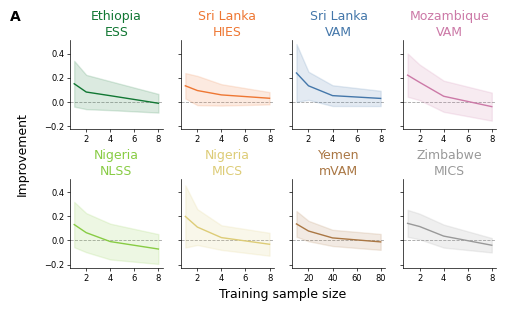

In [16]:
plot_metric_grid(
    df=plot_df,
    mean_col="imp_emd",
    std_col="emd_std",
    figure_title="Improvement in EMD across training sample sizes",
    out_path=OUT_DIR / "sensitivity_imp_emd_grid.png",
)

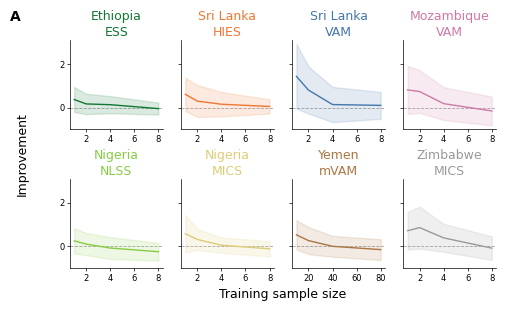

In [17]:
plot_metric_grid(
    df=plot_df,
    mean_col="imp_abs",
    std_col="abs_std",
    figure_title="Improvement in absolute mean error across training sample sizes",
    out_path=OUT_DIR / "sensitivity_imp_abs_grid.png",
)

In [40]:
def plot_two_metric_grids(
    df: pd.DataFrame,
    out_path: str | None = None,
    figsize: tuple = (6.0, 7.0),
):
    FS_TITLE = 9
    FS_AXES  = 9
    FS_TICK  = 6
    FS_PANEL = 10

    TITLE_LABELS = {
        "eth_micron": "Ethiopia\nESS",
        "lka_micron": "Sri Lanka\nHIES",
        "lka_vam":    "Sri Lanka\nVAM",
        "moz_vam":    "Mozambique\nVAM",
        "nga_micron": "Nigeria\nNLSS",
        "nga_mics":   "Nigeria\nMICS",
        "yem_mvam":   "Yemen\nmVAM",
        "zwe_mics":   "Zimbabwe\nMICS",
    }

    panels = [
        {
            "letter": "A",
            "mean_col": "imp_emd",
            "std_col": "emd_std",
            "ylabel": "Earth Mover's Distance\n Improvement over baseline",
        },
        {
            "letter": "B",
            "mean_col": "imp_abs",
            "std_col": "abs_std",
            "ylabel": "Mean Absolute Error\n Improvement over baseline",
        },
    ]

    # Better non-gray color for Zimbabwe
    EXPERIMENT_STYLE["zwe_mics"]["color"] = "#7B4F9D"

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        nrows=5,
        ncols=4,
        height_ratios=[1, 1, 0.2, 1, 1],  # row 2 is the spacer
        left=0.12,
        right=0.98,
        top=0.95,
        bottom=0.08,
        hspace=0.75,
        wspace=0.30,
    )

    axes_A = np.array([
        fig.add_subplot(gs[r, c])
        for r in range(2)
        for c in range(4)
    ])

    axes_B = np.array([
        fig.add_subplot(gs[r, c])
        for r in range(3, 5)
        for c in range(4)
    ])

    all_panel_axes = [axes_A, axes_B]

    for panel, panel_axes in zip(panels, all_panel_axes):
        for ax, exp in zip(panel_axes, experiment_order):
            sub = df[df["experiment"] == exp].sort_values("size").copy()
            style = EXPERIMENT_STYLE[exp]

            x = sub["size"].to_numpy(dtype=float)
            y = sub[panel["mean_col"]].to_numpy(dtype=float)
            s = sub[panel["std_col"]].to_numpy(dtype=float)

            ax.fill_between(
                x, y - s, y + s,
                alpha=0.15,
                color=style["color"],
                zorder=1,
            )

            ax.plot(
                x, y,
                linewidth=1.0,
                color=style["color"],
                zorder=2,
            )

            ax.axhline(
                0,
                linestyle="--",
                linewidth=0.6,
                color="0.55",
                alpha=0.8,
                zorder=0,
            )

            ax.set_title(
                TITLE_LABELS.get(exp, style.get("label", exp)),
                fontsize=FS_TITLE,
                fontweight="normal",
                color=style["color"],
                pad=3,
                linespacing=1.3,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(0.5)
            ax.spines["bottom"].set_linewidth(0.5)

            ax.locator_params(axis="x", nbins=4)
            ax.locator_params(axis="y", nbins=4)

            ax.tick_params(
                axis="x",
                labelsize=FS_TICK,
                pad=2,
                width=0.5,
                length=2.0,
            )

            ax.tick_params(
                axis="y",
                labelsize=FS_TICK,
                pad=2,
                width=0.5,
                length=2.0,
            )

            ax.grid(False)

        for ax in panel_axes[len(experiment_order):]:
            ax.axis("off")

    # Panel letters
    fig.text(
        0.01, 0.98,
        "A",
        fontsize=FS_PANEL,
        fontweight="bold",
        ha="left",
        va="top",
    )

    fig.text(
        0.01, 0.50,
        "B",
        fontsize=FS_PANEL,
        fontweight="bold",
        ha="left",
        va="top",
    )

    # Y-axis labels
    fig.text(
        0.025, 0.745,
        "Earth Mover's Distance (EMD)\n Improvement over baseline",
        fontsize=FS_AXES,
        ha="center",
        va="center",
        rotation=90,
    )

    fig.text(
        0.025, 0.265,
        "Mean Absolute Error (MAE)\n Improvement over baseline",
        fontsize=FS_AXES,
        ha="center",
        va="center",
        rotation=90,
    )

    # One shared x-axis label at the bottom
    fig.text(
        0.5, 0.025,
        "Training sample size",
        fontsize=FS_AXES,
        ha="center",
        va="bottom",
    )

    # One shared x-axis label at the bottom
    fig.text(
        0.5, 0.55,
        "Training sample size",
        fontsize=FS_AXES,
        ha="center",
        va="bottom",
    )

    if out_path is not None:
        out_base = str(Path(out_path).with_suffix(""))
        fig.savefig(out_path, dpi=400, bbox_inches="tight")
        fig.savefig(out_base + ".pdf", bbox_inches="tight")
        fig.savefig(out_base + ".svg", bbox_inches="tight")

    plt.show()

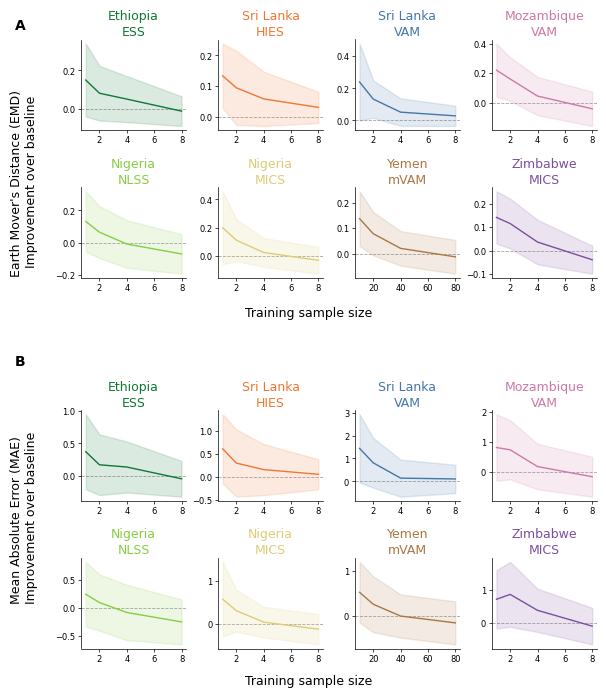

In [41]:
plot_two_metric_grids(
    df=plot_df,
    out_path=OUT_DIR / "sensitivity_two_panel_grid.png",
)

/tmp/ipykernel_1408019/2072229293.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_raw)


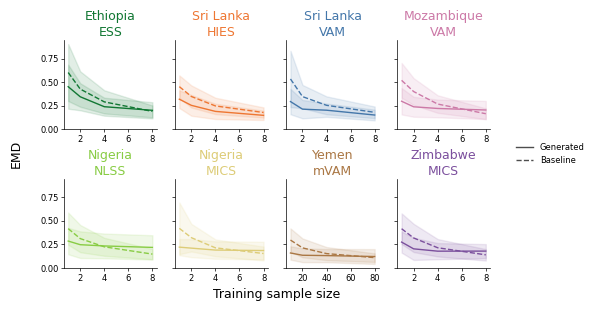

In [42]:
# ── recompute plot_df with separate baseline (emd_over) and gen (emd_gen) columns ──

group_cols = ["experiment", "size", "adm1_code", "target"]

seed_avg2 = (
    df.groupby(group_cols)
      .agg(
          emd_over_mean=("emd_over", "mean"),
          emd_gen_mean=("emd_gen",  "mean"),
          n_seeds=("emd_over", "count"),
      )
      .reset_index()
)

def agg_raw(group):
    return pd.Series({
        "emd_over":     group["emd_over_mean"].mean(),
        "emd_over_std": group["emd_over_mean"].std(ddof=1) if len(group) > 1 else 0.0,
        "emd_gen":      group["emd_gen_mean"].mean(),
        "emd_gen_std":  group["emd_gen_mean"].std(ddof=1) if len(group) > 1 else 0.0,
    })

plot_df2 = (
    seed_avg2.groupby(["experiment", "size"])
             .apply(agg_raw)
             .reset_index()
             .sort_values(["experiment", "size"])
             .reset_index(drop=True)
)
plot_df2[["emd_over_std", "emd_gen_std"]] = plot_df2[["emd_over_std", "emd_gen_std"]].fillna(0.0)
plot_df2["size"] = pd.to_numeric(plot_df2["size"], errors="coerce")

# ── plot: same grid style, two lines per subplot ──────────────────────────────

TITLE_LABELS = {
    "eth_micron": "Ethiopia\nESS",   "lka_micron": "Sri Lanka\nHIES",
    "lka_vam":    "Sri Lanka\nVAM",  "moz_vam":    "Mozambique\nVAM",
    "nga_micron": "Nigeria\nNLSS",   "nga_mics":   "Nigeria\nMICS",
    "yem_mvam":   "Yemen\nmVAM",     "zwe_mics":   "Zimbabwe\nMICS",
}
FS_TITLE, FS_AXES, FS_TICK = 9, 9, 6

fig, axes = plt.subplots(2, 4, figsize=(6.0, 3.0), sharex=False, sharey=True)
axes_flat = np.array(axes).reshape(-1)

for ax, exp in zip(axes_flat, experiment_order):
    sub   = plot_df2[plot_df2["experiment"] == exp].sort_values("size")
    style = EXPERIMENT_STYLE[exp]
    x     = sub["size"].to_numpy(dtype=float)

    for col, std_col, ls, lbl in [
        ("emd_over", "emd_over_std", "--", "Baseline"),
        ("emd_gen",  "emd_gen_std",  "-",  "Generated"),
    ]:
        y = sub[col].to_numpy(dtype=float)
        s = sub[std_col].to_numpy(dtype=float)
        ax.fill_between(x, y - s, y + s, alpha=0.12, color=style["color"])
        ax.plot(x, y, linewidth=1.0, color=style["color"], linestyle=ls, label=lbl)

    ax.set_title(
        TITLE_LABELS.get(exp, exp), fontsize=FS_TITLE,
        color=style["color"], pad=3, linespacing=1.3,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.5)
    ax.locator_params(axis="x", nbins=4)
    ax.locator_params(axis="y", nbins=4)
    ax.tick_params(axis="both", labelsize=FS_TICK, pad=2, width=0.5, length=2.0)

for ax in axes_flat[len(experiment_order):]:
    ax.axis("off")

# shared legend (solid = gen, dashed = baseline)
legend_lines = [
    plt.Line2D([0], [0], color="0.3", linewidth=1.0, linestyle="-",  label="Generated"),
    plt.Line2D([0], [0], color="0.3", linewidth=1.0, linestyle="--", label="Baseline"),
]
fig.legend(handles=legend_lines, fontsize=FS_TICK, loc="center right",
           bbox_to_anchor=(0.99, 0.5), frameon=False)

L, R, T, B = 0.11, 0.82, 0.88, 0.12
fig.subplots_adjust(left=L, right=R, top=T, bottom=B, hspace=0.55, wspace=0.20)
fig.text((L + R) / 2, 0.01, "Training sample size", fontsize=FS_AXES, ha="center", va="bottom")
fig.text(0.02, (B + T) / 2, "EMD", fontsize=FS_AXES, ha="left", va="center", rotation=90)

plt.savefig(OUT_DIR / "sensitivity_emd_contributions_grid.png", dpi=400, bbox_inches="tight")
plt.savefig(OUT_DIR / "sensitivity_emd_contributions_grid.pdf", bbox_inches="tight")
plt.show()

In [43]:
def make_raw_metric_plot_df(
    df: pd.DataFrame,
    over_col: str,
    gen_col: str,
    group_cols: list[str] = ["experiment", "size", "adm1_code", "target"],
):
    """
    Aggregates raw baseline/generated metric columns across seeds,
    then across adm1_code-target groups.

    Returns one row per experiment and size.
    """

    seed_avg = (
        df.groupby(group_cols)
          .agg(
              over_mean=(over_col, "mean"),
              gen_mean=(gen_col, "mean"),
              n_seeds=(over_col, "count"),
          )
          .reset_index()
    )

    def agg_raw(group):
        return pd.Series({
            "over":     group["over_mean"].mean(),
            "over_std": group["over_mean"].std(ddof=1) if len(group) > 1 else 0.0,
            "gen":      group["gen_mean"].mean(),
            "gen_std":  group["gen_mean"].std(ddof=1) if len(group) > 1 else 0.0,
        })

    plot_df = (
        seed_avg.groupby(["experiment", "size"])
                .apply(agg_raw)
                .reset_index()
                .sort_values(["experiment", "size"])
                .reset_index(drop=True)
    )

    plot_df[["over_std", "gen_std"]] = plot_df[["over_std", "gen_std"]].fillna(0.0)
    plot_df["size"] = pd.to_numeric(plot_df["size"], errors="coerce")

    return plot_df

In [47]:
def plot_two_metric_contribution_grids(
    df: pd.DataFrame,
    out_path: str | None = None,
    figsize: tuple = (6.0, 7.0),
):
    FS_TITLE = 9
    FS_AXES  = 9
    FS_TICK  = 6
    FS_PANEL = 10

    TITLE_LABELS = {
        "eth_micron": "Ethiopia\nESS",
        "lka_micron": "Sri Lanka\nHIES",
        "lka_vam":    "Sri Lanka\nVAM",
        "moz_vam":    "Mozambique\nVAM",
        "nga_micron": "Nigeria\nNLSS",
        "nga_mics":   "Nigeria\nMICS",
        "yem_mvam":   "Yemen\nmVAM",
        "zwe_mics":   "Zimbabwe\nMICS",
    }

    # Better non-gray color for Zimbabwe
    EXPERIMENT_STYLE["zwe_mics"]["color"] = "#7B4F9D"

    # Prepare the two panel datasets
    plot_emd = make_raw_metric_plot_df(
        df=df,
        over_col="emd_over",
        gen_col="emd_gen",
    )

    plot_abs = make_raw_metric_plot_df(
        df=df,
        over_col="absmeanerr_over",
        gen_col="absmeanerr_gen",
    )

    panels = [
        {
            "letter": "A",
            "plot_df": plot_emd,
            "ylabel": "Earth Mover's Distance (EMD)",
        },
        {
            "letter": "B",
            "plot_df": plot_abs,
            "ylabel": "Mean Absolute Error (MAE)",
        },
    ]

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        nrows=5,
        ncols=4,
        height_ratios=[1, 1, 0.2, 1, 1],
        left=0.12,
        right=0.82,   # leave room for shared legend
        top=0.95,
        bottom=0.08,
        hspace=0.75,
        wspace=0.30,
    )

    axes_A = np.array([
        fig.add_subplot(gs[r, c])
        for r in range(2)
        for c in range(4)
    ])

    axes_B = np.array([
        fig.add_subplot(gs[r, c])
        for r in range(3, 5)
        for c in range(4)
    ])

    all_panel_axes = [axes_A, axes_B]

    for panel, panel_axes in zip(panels, all_panel_axes):
        plot_df = panel["plot_df"]

        for ax, exp in zip(panel_axes, experiment_order):
            sub = plot_df[plot_df["experiment"] == exp].sort_values("size").copy()
            style = EXPERIMENT_STYLE[exp]

            x = sub["size"].to_numpy(dtype=float)

            for col, std_col, ls, lbl in [
                ("over", "over_std", "--", "Baseline"),
                ("gen",  "gen_std",  "-",  "Generated"),
            ]:
                y = sub[col].to_numpy(dtype=float)
                s = sub[std_col].to_numpy(dtype=float)

                ax.fill_between(
                    x, y - s, y + s,
                    alpha=0.12,
                    color=style["color"],
                    zorder=1,
                )

                ax.plot(
                    x, y,
                    linewidth=1.0,
                    color=style["color"],
                    linestyle=ls,
                    label=lbl,
                    zorder=2,
                )

            ax.set_title(
                TITLE_LABELS.get(exp, style.get("label", exp)),
                fontsize=FS_TITLE,
                fontweight="normal",
                color=style["color"],
                pad=3,
                linespacing=1.3,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(0.5)
            ax.spines["bottom"].set_linewidth(0.5)

            ax.locator_params(axis="x", nbins=4)
            ax.locator_params(axis="y", nbins=4)

            ax.tick_params(
                axis="x",
                labelsize=FS_TICK,
                pad=2,
                width=0.5,
                length=2.0,
            )

            ax.tick_params(
                axis="y",
                labelsize=FS_TICK,
                pad=2,
                width=0.5,
                length=2.0,
            )

            ax.grid(False)

        for ax in panel_axes[len(experiment_order):]:
            ax.axis("off")

    # Shared legend
    legend_lines = [
        plt.Line2D(
            [0], [0],
            color="0.3",
            linewidth=1.0,
            linestyle="-",
            label="Generated",
        ),
        plt.Line2D(
            [0], [0],
            color="0.3",
            linewidth=1.0,
            linestyle="--",
            label="Baseline",
        ),
    ]

    fig.legend(
        handles=legend_lines,
        fontsize=FS_TICK,
        loc="center right",
        bbox_to_anchor=(0.99, 0.50),
        frameon=False,
    )

    # Panel letters
    fig.text(
        0.01, 0.98,
        "A",
        fontsize=FS_PANEL,
        fontweight="bold",
        ha="left",
        va="top",
    )

    fig.text(
        0.01, 0.50,
        "B",
        fontsize=FS_PANEL,
        fontweight="bold",
        ha="left",
        va="top",
    )

    # Y-axis labels
    fig.text(
        0.025, 0.745,
        "Earth Mover's Distance (EMD)",
        fontsize=FS_AXES,
        ha="center",
        va="center",
        rotation=90,
    )

    fig.text(
        0.025, 0.265,
        "Mean Absolute Error (MAE)",
        fontsize=FS_AXES,
        ha="center",
        va="center",
        rotation=90,
    )

    # X-axis labels, symmetric with your previous figure
    fig.text(
        0.465, 0.55,
        "Training sample size",
        fontsize=FS_AXES,
        ha="center",
        va="bottom",
    )

    fig.text(
        0.465, 0.025,
        "Training sample size",
        fontsize=FS_AXES,
        ha="center",
        va="bottom",
    )

    if out_path is not None:
        out_base = str(Path(out_path).with_suffix(""))
        fig.savefig(out_path, dpi=400, bbox_inches="tight")
        fig.savefig(out_base + ".pdf", bbox_inches="tight")
        fig.savefig(out_base + ".svg", bbox_inches="tight")

    plt.show()

/tmp/ipykernel_1408019/2849234662.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_raw)
/tmp/ipykernel_1408019/2849234662.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_raw)


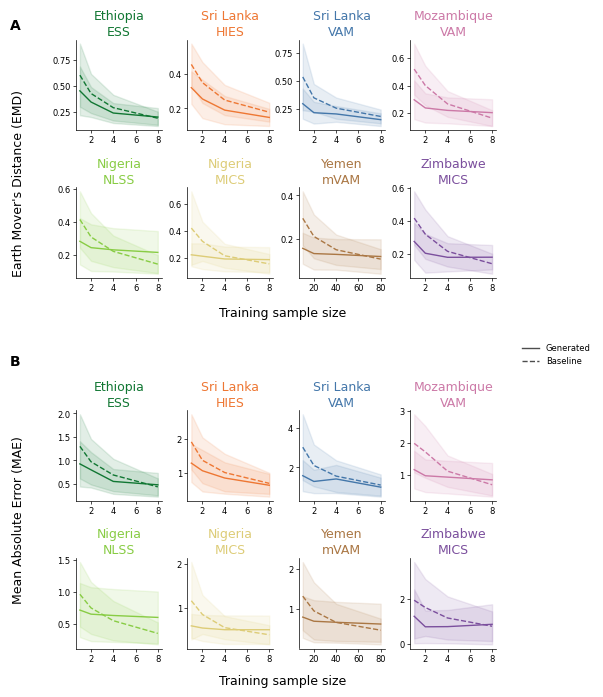

In [48]:
plot_two_metric_contribution_grids(
    df=df,
    out_path=OUT_DIR / "sensitivity_metric_contributions_two_panel_grid.png",
)